# **4. Recovery Analysis (Hangover Effects)**
## Coast-to-Coast Travel Analysis

This notebook examines:
- Performance in games FOLLOWING coast-to-coast travel
- How many games does it take to recover?
- Impact of rest days between games
- Cumulative fatigue from multiple trips

**Output**: Recovery patterns and hangover effect timelines

---
## **Load Data**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats

# Load enhanced schedule data
schedules = pd.read_csv('data_schedules_with_travel.csv')
schedules['gameday'] = pd.to_datetime(schedules['gameday'])


---
## **Identify Post-Travel Games**

For each team, find games that occur after coast-to-coast travel

In [13]:
# Create team schedule with all games (home and away)
all_teams = pd.unique(schedules[['home_team', 'away_team']].values.ravel())

team_schedules = []

for team in all_teams:
    # Get all games for this team
    home_games = schedules[schedules['home_team'] == team].copy()
    home_games['is_home'] = True
    home_games['team'] = team
    home_games['opponent'] = home_games['away_team']
    home_games['team_score'] = home_games['home_score']
    home_games['opp_score'] = home_games['away_score']
    home_games['travel_tz'] = 0  # No travel for home games
    
    away_games = schedules[schedules['away_team'] == team].copy()
    away_games['is_home'] = False
    away_games['team'] = team
    away_games['opponent'] = away_games['home_team']
    away_games['team_score'] = away_games['away_score']
    away_games['opp_score'] = away_games['home_score']
    away_games['travel_tz'] = away_games['tz_crossed']
    
    # Combine
    team_games = pd.concat([home_games, away_games])
    team_games = team_games.sort_values('gameday')
    
    # Add game number
    team_games['game_num'] = range(1, len(team_games) + 1)
    
    # Flag coast-to-coast games
    team_games['is_c2c'] = (team_games['travel_tz'] == 3) & (~team_games['is_home'])
    
    team_schedules.append(team_games)

full_schedule = pd.concat(team_schedules, ignore_index=True)

In [14]:
# Identify post-travel games
full_schedule = full_schedule.sort_values(['team', 'season', 'week'])
full_schedule['prev_c2c'] = full_schedule.groupby(['team', 'season'])['is_c2c'].shift(1).fillna(False)
full_schedule['days_since_prev_game'] = full_schedule.groupby(['team', 'season'])['gameday'].diff().dt.days

# Calculate win/loss
full_schedule['win'] = (full_schedule['team_score'] > full_schedule['opp_score']).astype(int)

print(f"Post-travel games identified: {full_schedule['prev_c2c'].sum()}")

Post-travel games identified: 96


---
## **Calculate Recovery Metrics**

How does performance change in post-travel games?

In [15]:
# Define categories
baseline = full_schedule[(~full_schedule['is_c2c']) & (~full_schedule['prev_c2c'])]
during_c2c = full_schedule[full_schedule['is_c2c']]
after_c2c = full_schedule[full_schedule['prev_c2c']]

# Calculate win rates
recovery_stats = pd.DataFrame({
    'Category': ['Baseline (No Recent C2C)', 'During C2C Travel', '1 Game After C2C'],
    'Win Rate': [
        baseline['win'].mean() * 100,
        during_c2c['win'].mean() * 100,
        after_c2c['win'].mean() * 100
    ],
    'Games': [
        len(baseline),
        len(during_c2c),
        len(after_c2c)
    ]
})

print("\n" + "="*70)
print("RECOVERY PATTERN: Win Rates\n")
print(recovery_stats.to_string(index=False))
print("="*70)


RECOVERY PATTERN: Win Rates

                Category  Win Rate  Games
Baseline (No Recent C2C) 50.287356   2088
       During C2C Travel 47.474747     99
        1 Game After C2C 40.625000     96


---
## **Visualize Recovery Timeline**

C:\Users\Sophy\AppData\Local\Temp\ipykernel_10892\3195094119.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


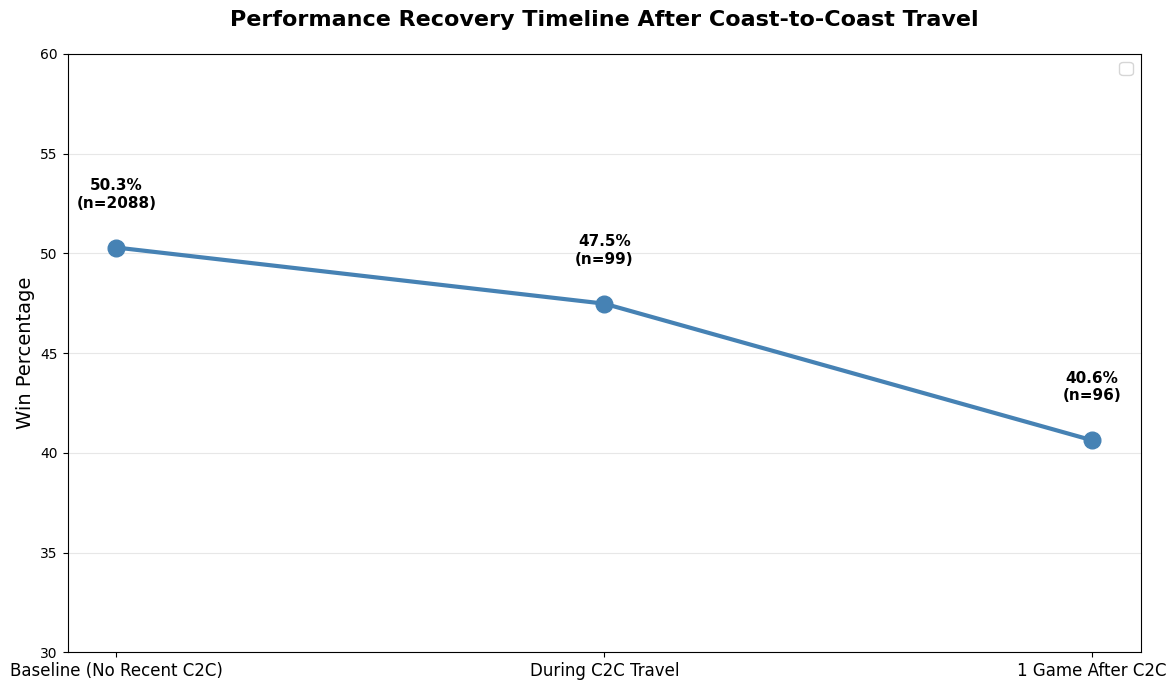

In [16]:
# Recovery timeline visualization
fig, ax = plt.subplots(figsize=(12, 7))

categories = recovery_stats['Category']
win_rates = recovery_stats['Win Rate']
games = recovery_stats['Games']

ax.plot(range(len(categories)), win_rates, marker='o', linewidth=3, 
        markersize=12, color='steelblue')


for i, (rate, n) in enumerate(zip(win_rates, games)):
    ax.text(i, rate + 2, f'{rate:.1f}%\n(n={n})', 
            ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Win Percentage', fontsize=14)
ax.set_title('Performance Recovery Timeline After Coast-to-Coast Travel', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(30, 60)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Impact of Rest Days**

Does more rest between games help recovery?

In [17]:
# Analyze rest days impact
post_c2c_with_rest = after_c2c[after_c2c['days_since_prev_game'].notna()].copy()

# Categorize rest
post_c2c_with_rest['rest_category'] = pd.cut(
    post_c2c_with_rest['days_since_prev_game'],
    bins=[0, 6, 7, 10, 100],
    labels=['Short Rest (3-6 days)', 'Normal Rest (7 days)', 
            'Extended Rest (8-10 days)', 'Long Rest (10+ days)']
)

rest_analysis = post_c2c_with_rest.groupby('rest_category', observed=True).agg({
    'win': ['mean', 'count']
}).reset_index()

rest_analysis.columns = ['Rest Period', 'Win Rate', 'Games']
rest_analysis['Win Rate'] = rest_analysis['Win Rate'] * 100

print("\n" + "="*70)
print("RECOVERY BY REST DAYS\n")
print(rest_analysis.to_string(index=False))
print("="*70)


RECOVERY BY REST DAYS

              Rest Period  Win Rate  Games
    Short Rest (3-6 days) 63.636364     11
     Normal Rest (7 days) 40.298507     67
Extended Rest (8-10 days) 30.000000     10
     Long Rest (10+ days) 25.000000      8


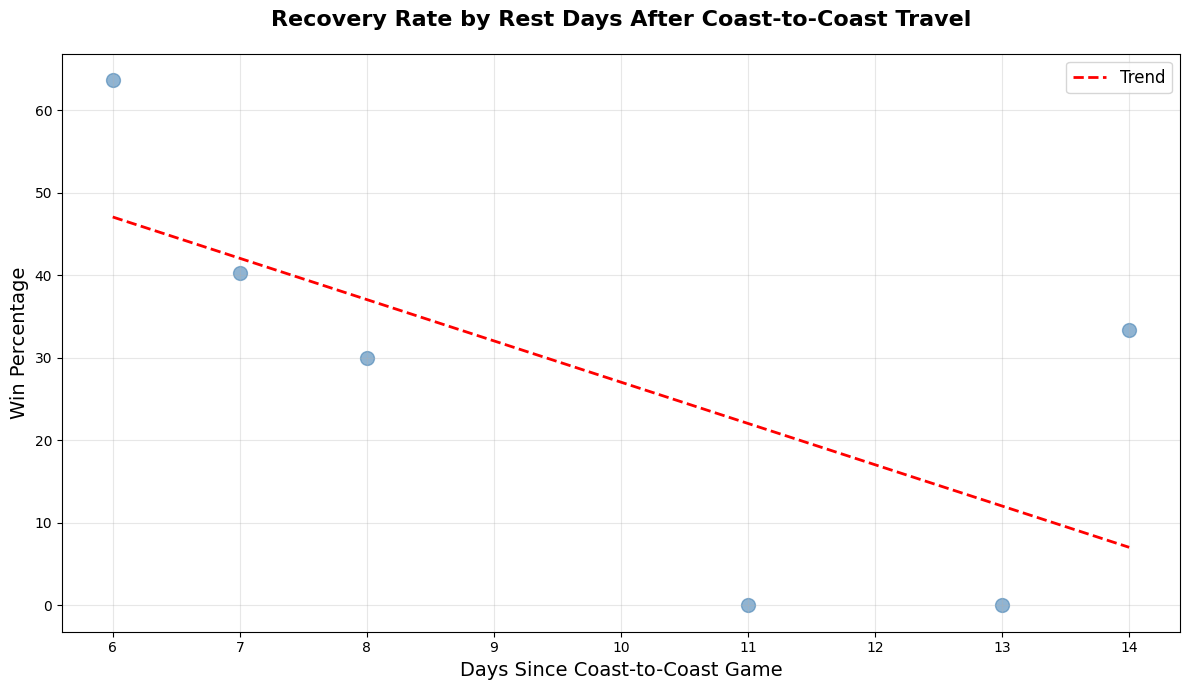

In [18]:
# Scatter plot: Days of rest vs Win rate
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate win rate by exact days
days_analysis = post_c2c_with_rest.groupby('days_since_prev_game').agg({
    'win': 'mean'
}).reset_index()

ax.scatter(days_analysis['days_since_prev_game'], 
           days_analysis['win'] * 100, 
           s=100, alpha=0.6, color='steelblue')

# Add trend line
z = np.polyfit(days_analysis['days_since_prev_game'], 
               days_analysis['win'] * 100, 1)
p = np.poly1d(z)
ax.plot(days_analysis['days_since_prev_game'], 
        p(days_analysis['days_since_prev_game']), 
        "r--", linewidth=2, label='Trend')


ax.set_xlabel('Days Since Coast-to-Coast Game', fontsize=14)
ax.set_ylabel('Win Percentage', fontsize=14)
ax.set_title('Recovery Rate by Rest Days After Coast-to-Coast Travel', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Multiple Trip Analysis**

Cumulative fatigue from back-to-back coast-to-coast games

In [19]:
# Calculate multiple C2C games (within last 4 weeks)
full_schedule = full_schedule.sort_values(['team', 'season', 'week'])

# Use transform instead of reset_index to maintain alignment
full_schedule['c2c_last_4weeks'] = (
    full_schedule.groupby(['team', 'season'])['is_c2c']
    .rolling(window=4, min_periods=1)
    .sum()
    .reset_index(level=[0, 1], drop=True)  # Drop both groupby levels
)

# Compare performance by number of recent C2C trips
cumulative_analysis = full_schedule.groupby('c2c_last_4weeks').agg({
    'win': ['mean', 'count']
}).reset_index()

cumulative_analysis.columns = ['C2C Games (Last 4 Weeks)', 'Win Rate', 'Games']
cumulative_analysis['Win Rate'] = cumulative_analysis['Win Rate'] * 100
cumulative_analysis = cumulative_analysis[cumulative_analysis['Games'] >= 20]  # Min sample size

print("\n" + "="*70)
print("CUMULATIVE FATIGUE: Multiple Coast-to-Coast Trips\n")
print(cumulative_analysis.to_string(index=False))
print("="*70)


CUMULATIVE FATIGUE: Multiple Coast-to-Coast Trips

 C2C Games (Last 4 Weeks)  Win Rate  Games
                      0.0 50.961039   1925
                      1.0 44.342508    327
                      2.0 38.461538     26


C:\Users\Sophy\AppData\Local\Temp\ipykernel_10892\2467240268.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


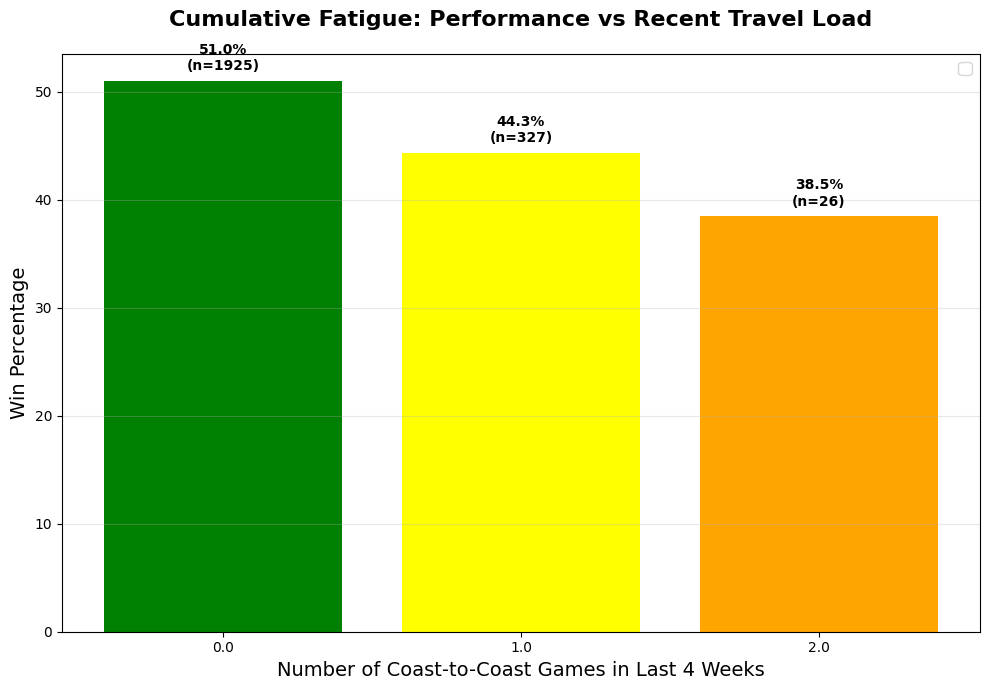

In [21]:
# Visualize cumulative effect
fig, ax = plt.subplots(figsize=(10, 7))

ax.bar(cumulative_analysis['C2C Games (Last 4 Weeks)'].astype(str), 
       cumulative_analysis['Win Rate'],
       color=['green', 'yellow', 'orange', 'red'][:len(cumulative_analysis)])

# Add values
for i, row in cumulative_analysis.iterrows():
    ax.text(i, row['Win Rate'] + 1, 
            f"{row['Win Rate']:.1f}%\n(n={int(row['Games'])})",
            ha='center', fontweight='bold')


ax.set_xlabel('Number of Coast-to-Coast Games in Last 4 Weeks', fontsize=14)
ax.set_ylabel('Win Percentage', fontsize=14)
ax.set_title('Cumulative Fatigue: Performance vs Recent Travel Load', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Statistical Testing**

In [23]:
# Test if hangover effect is significant
t_stat, p_value = stats.ttest_ind(
    after_c2c['win'],
    baseline['win']
)

print(f"\n{'='*70}")
print("STATISTICAL TEST: Post-Travel Hangover Effect")
print(f"Baseline Win Rate: {baseline['win'].mean()*100:.2f}% (n={len(baseline)})")
print(f"Post-C2C Win Rate: {after_c2c['win'].mean()*100:.2f}% (n={len(after_c2c)})")
print(f"Difference: {(baseline['win'].mean() - after_c2c['win'].mean())*100:.2f} percentage points")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")
print(f"{'='*70}")


STATISTICAL TEST: Post-Travel Hangover Effect
Baseline Win Rate: 50.29% (n=2088)
Post-C2C Win Rate: 40.62% (n=96)
Difference: 9.66 percentage points

T-statistic: -1.8520
P-value: 0.0642
Statistically significant: NO


---
## **Save Results**

In [24]:
recovery_stats.to_csv('recovery_timeline.csv', index=False)
rest_analysis.to_csv('rest_days_analysis.csv', index=False)
cumulative_analysis.to_csv('cumulative_fatigue.csv', index=False)


---
## **Summary**

**Expected Findings:**
- Hangover effects persist beyond immediate game
- Recovery takes multiple games or extended rest
- Cumulative fatigue from multiple trips compounds problems
- West Coast teams face more frequent cumulative burden